# 📊 OBV (On-Balance Volume) Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize the **On-Balance Volume (OBV)** indicator.  
OBV links **price** and **volume** to measure buying and selling pressure.

- When price closes **higher** than the previous close → add the day’s volume to OBV.  
- When price closes **lower** → subtract the day’s volume.  
- When price is unchanged → OBV stays flat.  

Traders use OBV to confirm price trends and detect divergences between price and volume.

---

## 🔹 Technical Background

### Formula
\[
OBV_t = OBV_{t-1} + 
\begin{cases} 
V_t, & \text{if } P_t > P_{t-1} \\
- V_t, & \text{if } P_t < P_{t-1} \\
0, & \text{if } P_t = P_{t-1}
\end{cases}
\]

Where:
- \( OBV_t \) = On-Balance Volume at time \(t\)  
- \( V_t \) = volume at time \(t\)  
- \( P_t \) = closing price at time \(t\)  


In [1]:
print("Hello World!")

Hello World!


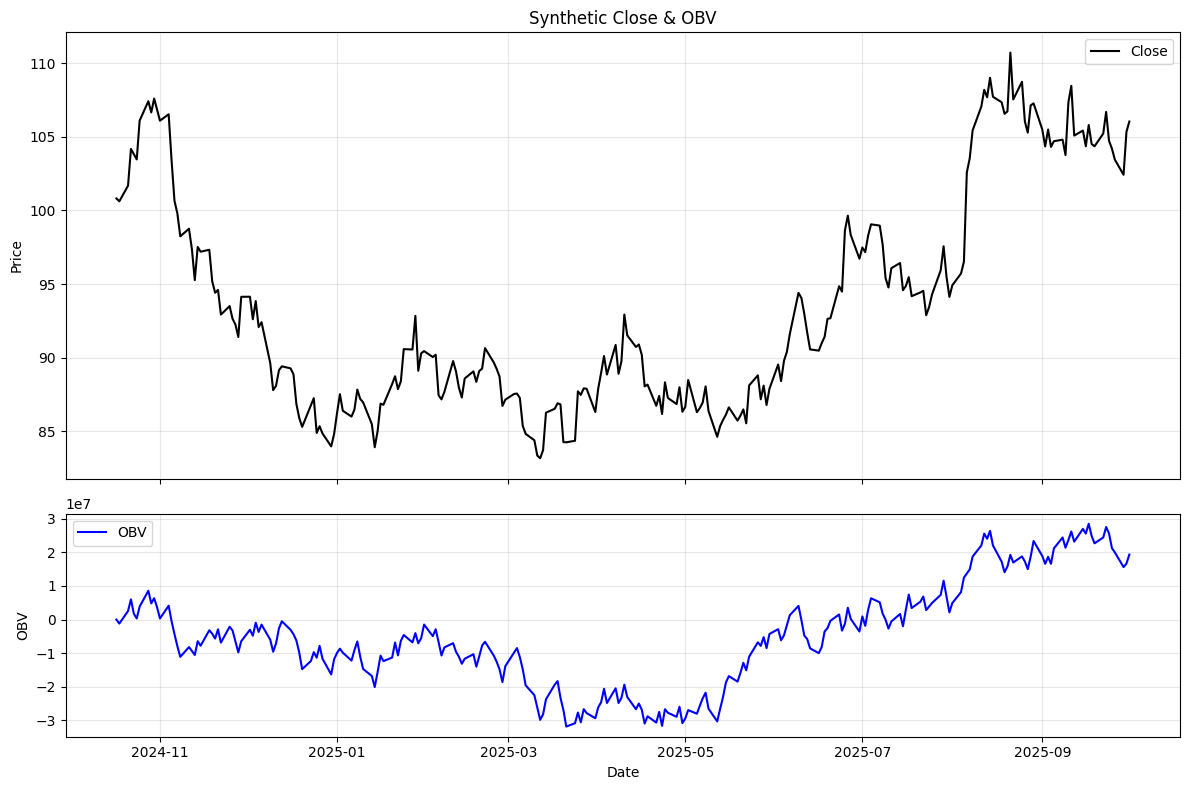

Mode: Synthetic
Rows: 250
Last Close: 106.04
Last OBV: 19349452


In [2]:
# ==== On-Balance Volume (OBV) Project ====
# Works with synthetic data by default. Set RUN_MODE="yfinance" for real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # used only if RUN_MODE="yfinance"
PERIOD     = "1y"
INTERVAL   = "1d"
# -------------------------

# 1) Load Data
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise RuntimeError("No data returned.")
        close = pd.to_numeric(df["Close"], errors="coerce").dropna()
        volume = pd.to_numeric(df["Volume"], errors="coerce").reindex(close.index).fillna(0)
        title = f"{TICKER} Close & OBV"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=250)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=len(dates))
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")

    # synthetic volume (random but scaled)
    volume = pd.Series(np.random.randint(1e6, 5e6, size=len(dates)), index=dates, name="Volume")

    title = "Synthetic Close & OBV"

# 2) Compute OBV
obv = [0]  # start at 0
for i in range(1, len(close)):
    if close.iloc[i] > close.iloc[i-1]:
        obv.append(obv[-1] + volume.iloc[i])
    elif close.iloc[i] < close.iloc[i-1]:
        obv.append(obv[-1] - volume.iloc[i])
    else:
        obv.append(obv[-1])  # unchanged if price == previous
obv = pd.Series(obv, index=close.index, name="OBV")

# 3) Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# Price chart
ax1.plot(close.index, close, label="Close", color="black")
ax1.set_title(title)
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend()

# OBV chart
ax2.plot(obv.index, obv, label="OBV", color="blue")
ax2.set_ylabel("OBV")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 4) Summary
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(close))
print("Last Close:", round(close.iloc[-1],2))
print("Last OBV:", round(obv.iloc[-1],2))
